In [21]:
import pandas as pd
import numpy as np

In [22]:
df=pd.read_csv("powerplant_data.csv")   

In [23]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [24]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [25]:
x=df.drop("PE",axis=1)
y=df["PE"]

In [26]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [27]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [28]:
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [29]:
from torch.utils.data import TensorDataset, DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [30]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=32, shuffle=False)

In [31]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),
            nn.Linear(6, 6),
            nn.ReLU(),
            nn.Linear(6, 1)
    )

    def forward(self,x):
        return self.model(x)

In [32]:
import torch.optim as optim
model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [36]:
train_losses = []
val_losses = []


epoch=50
for epoch in range(epoch):
    model.train()
    running_loss=0.0
    for xb,yb in train_loader:
        output=model(xb)
        loss=criterion(output,yb)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        running_loss+=loss.item()
    epoch_loss=running_loss/len(train_loader)
    train_losses.append(epoch_loss)

    running_loss=0.0
    model.eval()
    with torch.no_grad():
        for xb,yb in test_loader:
            output=model(xb)
            loss=criterion(output,yb)
            running_loss+=loss.item()
    epoch_loss=running_loss/len(test_loader)
    val_losses.append(epoch_loss)

    print(f"Epoch {epoch+1}/{epoch}, Train Loss: {train_losses[-1]:.4f}, Val Loss: {val_losses[-1]:.4f}")
    

Epoch 1/0, Train Loss: 20.4396, Val Loss: 18.7741
Epoch 2/1, Train Loss: 20.5402, Val Loss: 18.9620
Epoch 3/2, Train Loss: 20.4971, Val Loss: 18.5742
Epoch 4/3, Train Loss: 20.6317, Val Loss: 18.6571
Epoch 5/4, Train Loss: 20.4229, Val Loss: 18.6736
Epoch 6/5, Train Loss: 20.5475, Val Loss: 19.2336
Epoch 7/6, Train Loss: 20.6157, Val Loss: 18.7929
Epoch 8/7, Train Loss: 20.4223, Val Loss: 18.9731
Epoch 9/8, Train Loss: 20.4435, Val Loss: 18.7465
Epoch 10/9, Train Loss: 20.3652, Val Loss: 18.6098
Epoch 11/10, Train Loss: 20.3663, Val Loss: 18.7203
Epoch 12/11, Train Loss: 20.4932, Val Loss: 18.6489
Epoch 13/12, Train Loss: 20.5162, Val Loss: 19.2653
Epoch 14/13, Train Loss: 20.4886, Val Loss: 19.6909
Epoch 15/14, Train Loss: 20.5095, Val Loss: 18.5895
Epoch 16/15, Train Loss: 20.4755, Val Loss: 18.7143
Epoch 17/16, Train Loss: 20.5268, Val Loss: 18.5235
Epoch 18/17, Train Loss: 20.4356, Val Loss: 18.5202
Epoch 19/18, Train Loss: 20.4163, Val Loss: 18.6422
Epoch 20/19, Train Loss: 20.435

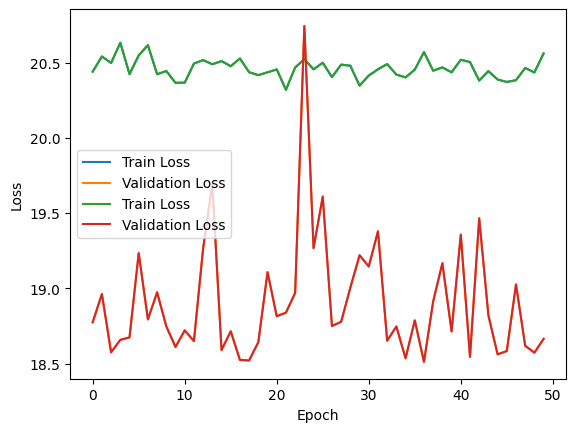

In [37]:
import matplotlib.pyplot as plt
pd.DataFrame({"Train Loss": train_losses, "Validation Loss": val_losses}).plot()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


In [38]:
model.load_state_dict(torch.load("best_model.pth"))

<All keys matched successfully>

In [39]:
model.eval()
with torch.no_grad():
    train_predictions = model(X_train_tensor)
    test_predictions = model(X_test_tensor)

    train_mse_loss=criterion(train_predictions, y_train_tensor).item()
    test_mse_loss=criterion(test_predictions, y_test_tensor).item()

print(f"Final Train MSE Loss: {train_mse_loss:.4f}")
print(f"Final Test MSE Loss: {test_mse_loss:.4f}")

Final Train MSE Loss: 20.2971
Final Test MSE Loss: 18.8738


In [40]:
from sklearn.metrics import r2_score
print(f"Train R² Score: {r2_score(y_train_tensor.numpy(), train_predictions.numpy()):.4f}")

Train R² Score: 0.9306


In [41]:
predicted_df=pd.DataFrame({"Actual": y_test_tensor.numpy().flatten(), "Predicted": test_predictions.numpy().flatten()})
print(predicted_df.head())

       Actual   Predicted
0  433.269989  435.930969
1  438.160004  437.265656
2  458.420013  461.714752
3  480.820007  476.451599
4  441.410004  435.959595
